# 5. Simple image filtering


## Setup and image loading


In [69]:
import inspect
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal
import IPython.display
%matplotlib widget
from cued_sf2_lab.familiarisation import load_mat_img, plot_image
from cued_sf2_lab.simple_image_filtering import halfcos, convse

In [70]:
%load_ext jupyter_tikz
#loads tikz display in jupyter

The jupyter_tikz extension is already loaded. To reload it, use:
  %reload_ext jupyter_tikz


## Half-cosine lowpass filter


In [71]:
# load the image as we did before
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})

An effective image lowpass filter, of odd length $N$, may be obtained by defining the impulse
response $h(n)$ to be a sampled half-cosine pulse:

$$h(n) = G \cos \left(\frac{n\pi}{N + 1}\right),\qquad \text{for} \qquad \frac{-(N - 1)}{2} \le n \le \frac{N - 1}{2}$$

where $G$ is a gain factor, which, in order to give unity gain at zero frequency, should be calculated such that

$$\sum_{n=-(N-1)/2}^{(N-1)/2} h(n) = 1$$

(This may be done most easily by first calculating h(n) with G = 1, summing all terms,
and then dividing them all by the result.)

Take a look at the `halfcos` function below and check that it generates h for a given N:


## Filtering rows with `np.convolve`


In [72]:
# this is just to make it appear in a cell - you can use `halfcos??` to quickly read any function
#IPython.display.Code(inspect.getsource(halfcos), language="python")

halfcos??

Signature: halfcos(N: int) -> numpy.ndarray
Source:   
def halfcos(N: int) -> np.ndarray:
    """
    Create a half-cosine function of length N samples.

    Parameters:
        N: Usually odd.
    Returns:
        h: discrete samples of the half-cosine
    """
    # The amplitude gives unit gain at zero frequency.
    h = np.cos((np.array(range(1, N+1))/(N+1) - 0.5) * np.pi)
    h = h / sum(h)
    return h
File:      ~/iia-all/sf2/cued_sf2_lab/simple_image_filtering.py
Type:      function

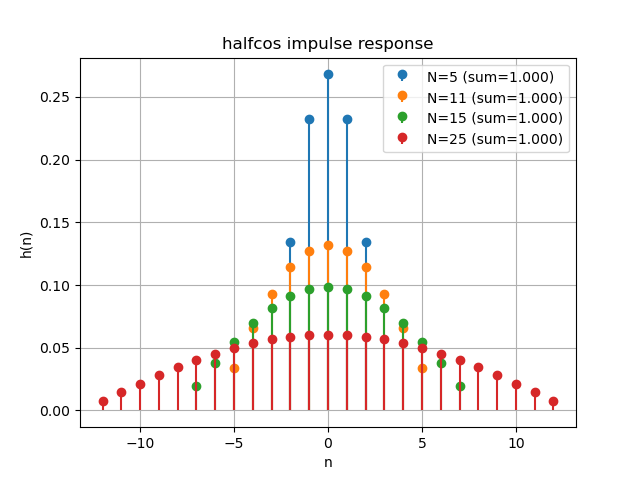

In [73]:
# visualise halfcos for a few odd lengths to understand its shape
fig, ax = plt.subplots()
for i, N in enumerate([5, 11, 15, 25]):
    h = halfcos(N)
    n = np.arange(-(N - 1) // 2, (N - 1) // 2 + 1)
    ax.stem(n, h, linefmt=f'C{i}-', markerfmt=f'C{i}o', basefmt=' ', label=f'N={N} (sum={h.sum():.3f})')
ax.set_xlabel('n')
ax.set_ylabel('h(n)')
ax.set_title('halfcos impulse response')
ax.legend()
ax.grid(True)

Use the [`np.convolve` function in a for loop](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) to convolve a 15-sample half-cosine with each row of the test image, Lighthouse.

Observe the resulting image `Xf` and note the increased width and the gradual fade to black at the edges, caused by the `convolve` assuming the signal is zero outside the range of the input vectors (the behavior when `mode='full'`).


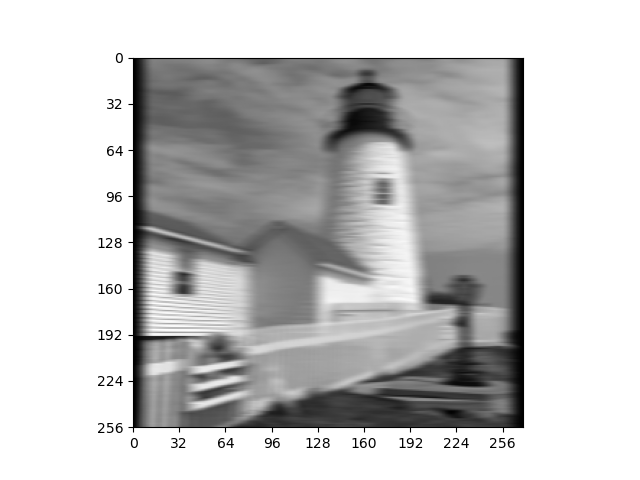

In [74]:
# your code here

fig, ax = plt.subplots()

n, m = X.shape
hc=halfcos(15)
Xf = np.zeros((n, m + len(hc) - 1))

for row_idx in range(X.shape[0]):
    Xf[row_idx] = np.convolve(X[row_idx],hc)

plot_image(Xf, ax=ax)

Trim the filtered image `Xf` to its correct size using `Xf[:, 7:256+7]` and display it:


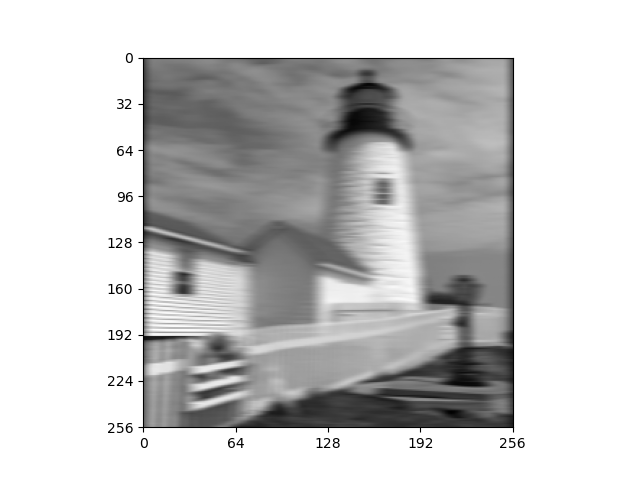

In [75]:
Xf = Xf[:, 7:256+7]
fig, ax = plt.subplots()
plot_image(Xf, ax=ax)

Note that darkening of the sides is still visible, since the lowpass filter
assumes that the intensity is zero outside the image.


### Numpy convolve modes

For an input signal $x$ of length $N$ and a kernel $h$ of length $K$, the discrete convolution is

$$
y[n] = \sum_{k} x[k]\, h[n-k].
$$

The three `mode` options of `np.convolve` (and `scipy.signal.convolve`) differ only in **which output indices $n$ are kept**:

- **`full`** — every $n$ for which the sum has at least one non-zero term. The kernel is allowed to hang off either edge of the signal (the missing samples are treated as zero).

  $$
  n \in [0,\; N + K - 2], \qquad \text{length}\; N + K - 1.
  $$

- **`same`** — output truncated to the same length as the input, centred on the `full` result. With $K$ odd this exactly removes the $(K-1)/2$ leading and trailing "transient" samples.

  $$
  n \in \left[\tfrac{K-1}{2},\; N + \tfrac{K-1}{2} - 1\right], \qquad \text{length}\; N.
  $$

- **`valid`** — only indices where the kernel is **fully overlapped** by the signal (no zero-padding involved). This is the shortest, edge-effect-free output.

  $$
  n \in [K-1,\; N - 1], \qquad \text{length}\; N - K + 1.
  $$


The picture below shows a small example with $N=5$, $K=3$. Each row is the kernel placed at a different output index $n$; the shaded squares are the signal samples actually multiplied (grey squares are implicit zeros from padding).


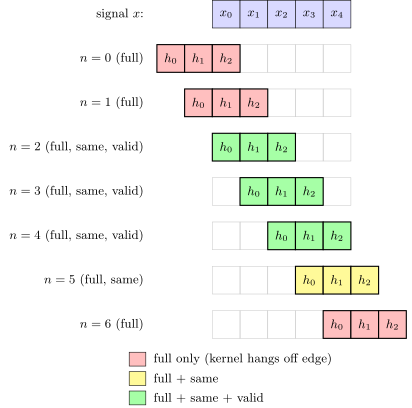

In [76]:
%%tikz -sc=1.4
\begin{tikzpicture}[scale=0.7, every node/.style={font=\small}]
  % signal label sits well left of any kernel cell (min col = -2)
  \node[left] at (-2.3,0.5) {signal $x$:};
  \foreach \i in {0,...,4} {
    \draw[fill=blue!15] (\i,0) rectangle (\i+1,1);
    \node at (\i+0.5,0.5) {$x_{\i}$};
  }

  \newcommand{\krow}[4]{%
    \begin{scope}[yshift=#1 cm]
      \node[left] at (-2.3,0.5) {#3};
      \foreach \i in {0,...,4} {
        \draw[gray!40] (\i,0) rectangle (\i+1,1);
      }
      \foreach \k in {0,1,2} {
        \pgfmathtruncatemacro{\col}{#2+\k}
        \draw[fill=#4, thick] (\col,0) rectangle (\col+1,1);
        \node at (\col+0.5,0.5) {$h_{\k}$};
      }
    \end{scope}}

  \krow{-1.6}{-2}{$n=0$ (full)}{red!25}
  \krow{-3.2}{-1}{$n=1$ (full)}{red!25}
  \krow{-4.8}{0}{$n=2$ (full, same, valid)}{green!35}
  \krow{-6.4}{1}{$n=3$ (full, same, valid)}{green!35}
  \krow{-8.0}{2}{$n=4$ (full, same, valid)}{green!35}
  \krow{-9.6}{3}{$n=5$ (full, same)}{yellow!40}
  \krow{-11.2}{4}{$n=6$ (full)}{red!25}

  \begin{scope}[yshift=-13.6cm, xshift=-3cm]
    \draw[fill=red!25]    (0,1.4) rectangle (0.6,1.9);
    \node[right] at (0.7,1.65) {full only (kernel hangs off edge)};
    \draw[fill=yellow!40] (0,0.7) rectangle (0.6,1.2);
    \node[right] at (0.7,0.95) {full + same};
    \draw[fill=green!35]  (0,0.0) rectangle (0.6,0.5);
    \node[right] at (0.7,0.25) {full + same + valid};
  \end{scope}
\end{tikzpicture}

Image trimming and convolution of all the image rows can also be achieved using the [`scipy.signal.convolve`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html) function with the `mode='same'` argument. Note we have to turn `h` into a 2d filter by wrapping it in `[]`:

```python
Xf = scipy.signal.convolve(X, [h])
```


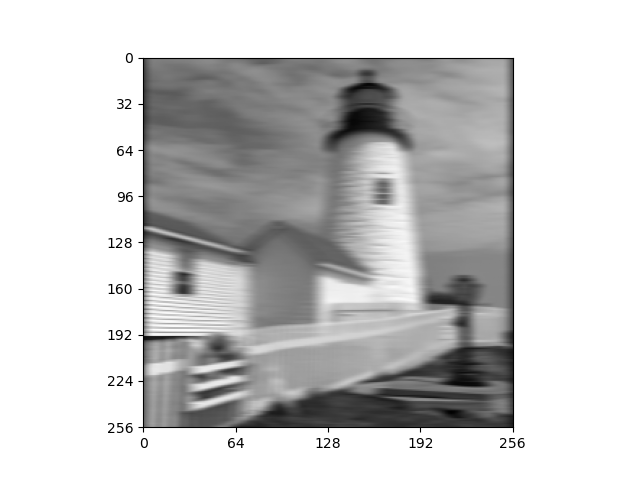

In [77]:
# your code here - use `scipy.signal.convolve` instead of the for loop containing `np.convolve`:
fig, ax = plt.subplots()

# define a 15-sample halfcosine
h = halfcos(15)
Xf = scipy.signal.convolve(X, [h], mode='same')

plot_image(Xf, ax=ax);

## Symmetric extension with `convse`


Symmetric extension is a technique to minimise edge effects when images of
finite size are filtered. It assumes that the image is surrounded by a
flat mirror along each edge so it extends into mirror-images (symmetric
extensions) of itself in all directions over an infinite plane. If the filter
impulse response is symmetrical about its mid point, then the filtered image
will also be symmetrically extended in all directions with the same period as
the original images. Hence it is only necessary to define the filtered image
over the same area as the original image, for it to be defined over the whole
infinite plane.

Let us consider a one-dimensional example for a 4-point input signal
$a,b,c,d$. This may be symmetrically extended in one of two ways:

$$
 \ldots d,c,b,\underbrace{a,b,c,d,}_{\text{original}}c,b,a \ldots
\quad \text{or} \quad
 \ldots d,c,b,a,\underbrace{a,b,c,d,}_{\text{original}}d,c,b,a \ldots
$$

> left is reflect right is symmetric

The left-hand method, where the end points are not repeated at each boundary, is most
suitable when the signal is to be filtered by a filter of odd length. The other method is most suited to filters of even length.

In Python, a matrix with symmetrically extended rows can be obtained with [`np.pad`](https://numpy.org/doc/stable/reference/generated/numpy.pad.html) using the `reflect` and `symmetric` modes:


In [78]:
x = np.array([
    ["a", "b", "c", "d"],
    ["A", "B", "C", "D"]])
print(np.pad(x, [(0, 0), (2, 2)], mode='reflect'))    # for filters of odd length
print()
print(np.pad(x, [(0, 0), (2, 2)], mode='symmetric'))  # for filters of even length

[['c' 'b' 'a' 'b' 'c' 'd' 'c' 'b']
 ['C' 'B' 'A' 'B' 'C' 'D' 'C' 'B']]

[['b' 'a' 'a' 'b' 'c' 'd' 'd' 'c']
 ['B' 'A' 'A' 'B' 'C' 'D' 'D' 'C']]


In [79]:
#IPython.display.Code(inspect.getsource(convse), language="python")

convse??

Signature: convse(X: numpy.ndarray, h: numpy.ndarray) -> numpy.ndarray
Source:   
def convse(X: np.ndarray, h: np.ndarray) -> np.ndarray:
    """
    Filter rows of image X using filter h with symmetric extension of X.

    Parameters:
        X: Image matrix (Usually 256x256)
        h: Filter coefficients
    Returns:
        Y: Row - Filtered image

    PS: Need to apply `convse` twice to filter rows and columns.
    """
    r, c = X.shape
    m = len(h)
    m2 = m // 2
    if m % 2:
        X = np.pad(X, [(0, 0), (m2, m2)], mode='reflect')
    else:
        X = np.pad(X, [(0, 0), (m2, m2)], mode='symmetric')

    Y = np.zeros((r, c))
    # Loop for each term in h. This loop is the convolution.
    for i in range(m):
        Y = Y + h[i] * X[:, i:i+c]
    return Y
File:      ~/iia-all/sf2/cued_sf2_lab/simple_image_filtering.py
Type:      function

**What `convse` does.** Pad each row of `X` by $m_2 = \lfloor m/2 \rfloor$ samples on each side (`reflect` for odd $m$, `symmetric` for even $m$), then accumulate $m$ shifted slices of the padded image, each scaled by one filter tap:

$$
Y \mathrel{+}= h[i] \cdot X_\text{pad}[:,\; i:i+c], \qquad i = 0, \dots, m-1.
$$

With $x_\text{pad}[t] = x_\text{ext}[t - m_2]$, this gives

$$
y[j] \;=\; \sum_{i=0}^{m-1} h[i]\, x_\text{pad}[j+i]
     \;=\; \sum_{k=-m_2}^{m_2} h[k + m_2]\, x_\text{ext}[j + k],
$$

i.e. a **centred** correlation of the symmetrically-extended row with $h$ (= convolution when $h$ is symmetric). The $m_2$ samples of padding are exactly what each output $j$ needs to see the full window $[j-m_2,\, j+m_2]$ without falling off the edge.


Note that this `convse` is actually provided as part of scipy, as [`scipy.ndimage.convolve1d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve1d.html), but `convse` is much easier to understand the implementation of.

Use `convse` to filter the rows of your image with the
15-tap half-cosine filter, noting the absence of edge effects.


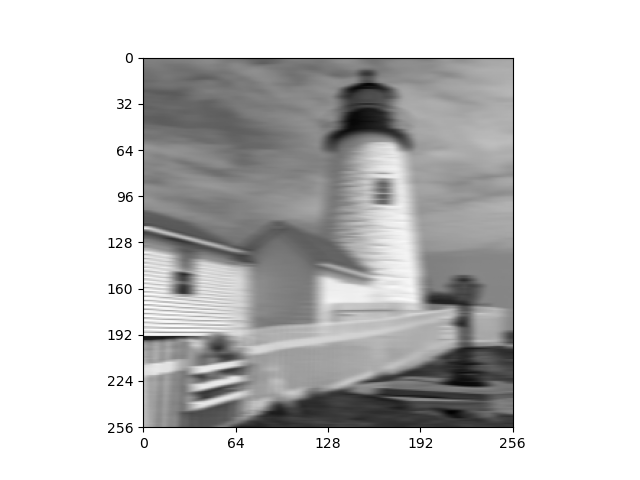

In [80]:
Xrpad=convse(X,hc)
fig, ax = plt.subplots()
plot_image(Xrpad, ax=ax);

## Separable 2-D filtering


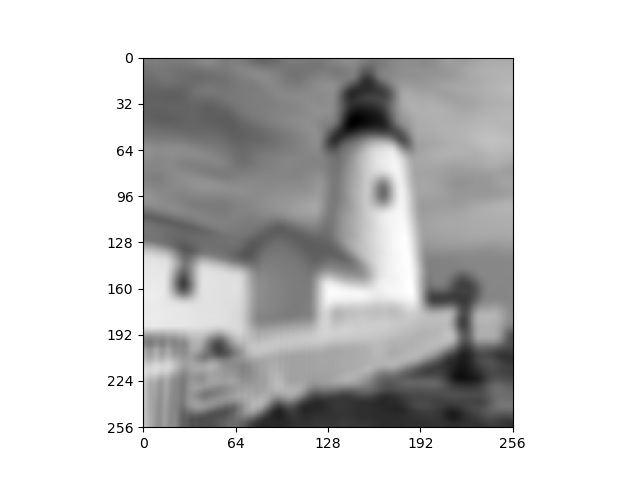

In [81]:
Xrcpad=convse(Xrpad.T,hc).T
fig, ax = plt.subplots()
plot_image(Xrcpad, ax=ax);

<div class="alert alert-block alert-danger">

Does it make any difference whether the rows or columns are filtered first? (You should test this accurately by measuring the maximum absolute pixel difference between the row-column and column-row filtered images. Beware of scientific notation, used by Python for very small numbers!)

</div>


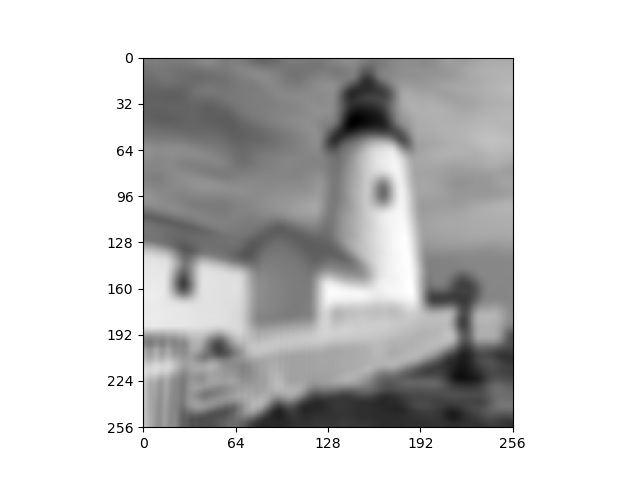

In [82]:
Xcpad=convse(X.T,hc).T
Xcrpad=convse(Xcpad,hc)
fig, ax = plt.subplots()
plot_image(Xcrpad, ax=ax);

In [83]:
mae=np.abs(Xrcpad-Xcrpad).sum()
print(mae)

1.1206928718365816e-09


This process of separate row and column filtering is known as
_separable_ 2-D filtering, and is much more efficient than
the more general non-separable 2-D filtering.


## Highpass filters and image energy


It is possible to construct a 2-D _high-pass_ filter by subtracting the 2-D low-pass
result from the original. Note that your 2-D lowpass filter `h` _must_ have a DC gain (sum of all filter coefficients) of unity for this to correctly produce a highpass filter. The
highpass image `Y` now contains negative, as well as positive
pixel values, so it is sensible to display the result using `imshow(Y)` which automatically compensates for this.


Explain in the report why lowpass and highpass filter


<div class="alert alert-block alert-danger">

Try generating both low-pass and high-pass versions of `X` using a range of different odd-length half-cosine filters. Comment on the relative effects of these filters

</div>


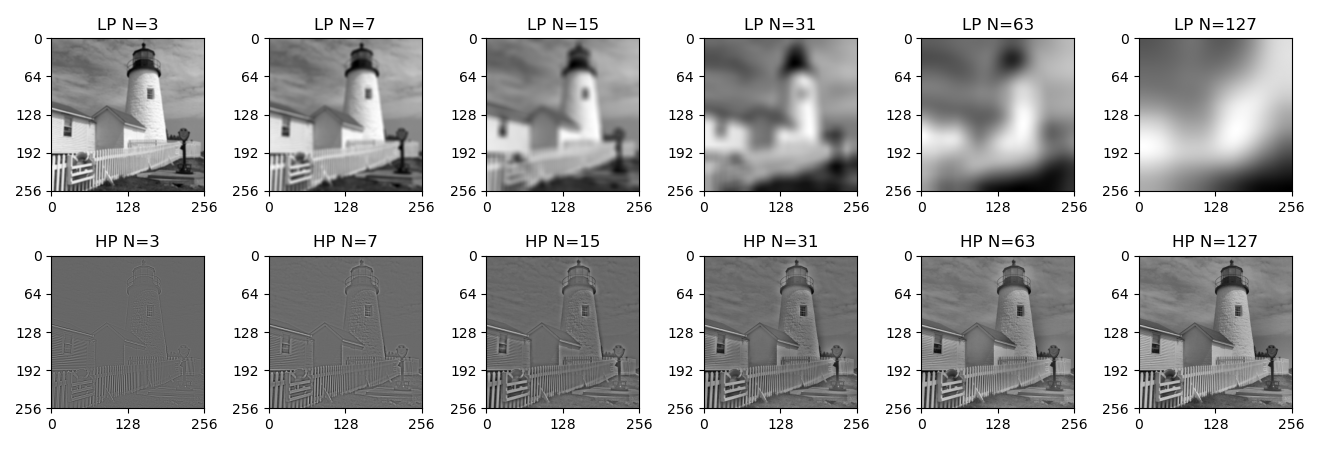

In [84]:
lengths = [3, 7, 15, 31, 63, 127]

#results of the lowpass and highpass filters, of differing filter lengths
lowpass = {}
highpass = {}
for L in lengths:
    h = halfcos(L)
    Xlp = convse(convse(X, h).T, h).T   # 2-D lowpass: rows first then columns
    lowpass[L] = Xlp
    highpass[L] = X - Xlp                # highpass = original - lowpass

# show all of them
fig, axes = plt.subplots(2, len(lengths), figsize=(2.2*len(lengths), 4.5))
for j, L in enumerate(lengths):
    plot_image(lowpass[L],  ax=axes[0, j]); axes[0, j].set_title(f'LP N={L}')
    plot_image(highpass[L], ax=axes[1, j]); axes[1, j].set_title(f'HP N={L}')
fig.tight_layout()
fig.savefig('zach/images/lp_hp_montage.png', dpi=150, bbox_inches='tight')

One way to assess sets of filtered images like these is to contrast the _energy_ content. In this context, the energy `E` of an image `X` is given by the sum of the squares of the individual pixel values:

```python
E = np.sum(X**2.0)
```

Remember that $a^b$ is spelt `a**b` in Python, not `a^b`. We make sure to use `2.0` and not `2`, as `np.array(16, dtype=np.uint8)**2` overflows the bounds of `uint8` and gives `0`, while `2.0` tells numpy to use at least `float64` instead.


<div class="alert alert-block alert-danger">
What do you observe about the energy of the highpass images, compared with that of the lowpass images?
</div>


In [85]:
E_X = np.sum(X**2.0)
print(f'energy of original X: {E_X:.3e}\n')
print(f'{"N":>4} {"E(LP)":>12} {"E(HP)":>12} {"E(LP)+E(HP)":>14}')
for L in lengths:
    Elp = np.sum(lowpass[L]**2.0)
    Ehp = np.sum(highpass[L]**2.0)
    print(f'{L:>4} {Elp:>12.3e} {Ehp:>12.3e} {Elp+Ehp:>14.3e}')

energy of original X: 1.317e+09

   N        E(LP)        E(HP)    E(LP)+E(HP)
   3    1.290e+09    1.547e+07      1.306e+09
   7    1.273e+09    3.087e+07      1.304e+09
  15    1.256e+09    4.795e+07      1.304e+09
  31    1.236e+09    6.273e+07      1.299e+09
  63    1.211e+09    8.397e+07      1.295e+09
 127    1.184e+09    1.109e+08      1.295e+09


- Energy of LP filter is higher than that of HP filter
- Both sum to roughly the total energy
  - However as filter length increases, total energy seems to decrease slightly
